In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn #nn contains all of pytorch's building blocks for neural networks
torch.__version__

'2.5.1+cu121'

Neural network with classification

#1.Make classification data and get it ready

In [3]:
import sklearn
from sklearn.datasets import make_circles

#make 1000 samples
n_sample=1000

#create circles
X,y=make_circles(n_sample,noise=0.03,random_state=42) 

In [4]:
len(X),len(y)

(1000, 1000)

In [5]:
print(f"first 5 samples of x\n:{X[:5]}")
print(f"first 5 samples of y\n:{y[:5]}")

first 5 samples of x
:[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of y
:[1 1 1 1 0]


In [6]:
#make a dataframe of circle data
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


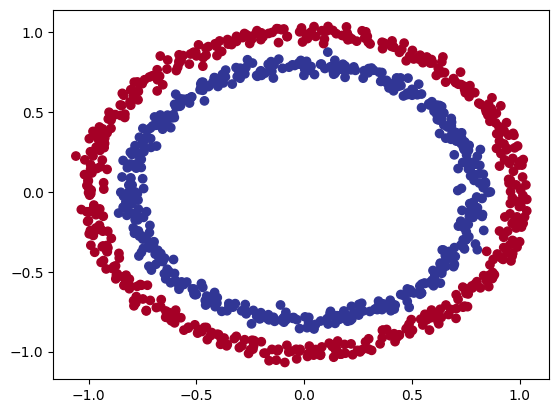

In [7]:
#visualize,visualize and visualize
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu) #color map

In [8]:
#1.1 check input and output shapes
X.shape,y.shape


((1000, 2), (1000,))

In [9]:
#view the first example of features and labels
X_sample=X[0]
y_sample=y[0]

print(f"values for one sample of x:{X_sample} and the same for y:{y_sample}")
print(f"Shape for one sample of x:{X_sample.shape} and the same for y:{y_sample.shape}")


values for one sample of x:[0.75424625 0.23148074] and the same for y:1
Shape for one sample of x:(2,) and the same for y:()


In [10]:
#1.2 turn data into tensors and create train and test splits
#turn data into tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
#split data into training and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#2.Building Model

In [12]:
#let's build a model to classify our blue and red dots
#1.setup deivces agnostic code so our code will run on an acceleartor (GPU) if there is one
#2.construct a model by subclassing nn.Module
#3.Define a loss function and optimizer
#4.create a training and testing loop and train the model

from torch import nn

#make device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [13]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [14]:
#now we've have setup device agnostic code,let's create a model that:
#1.subclasses nn.Module (almost all models in pytorch subclass nn.Module)
#2.create nn.linear() layers that are capable of handing the shape of our data
#3.define a forward() method that outlines the forward pass
#4.instantiate a instance of our model and send it to the target device

In [15]:
#1.construct a model by subclassing nn.Module
class circlemodelv0(nn.Module):
    def __init__(self):
        super().__init__()
        #2.create nn.linear layers capable of handling the shape of our data
        self.layer_1=nn.Linear(in_features=2,out_features=5)
        self.layer_2=nn.Linear(in_features=5,out_features=1)
    
    #3.define a forwar() method that outline the forward pass
    def forward(self,x):
        return self.layer_2(self.layer_1(x))#x->layer_1->layer_2->output
    
#4.instantiate a instance of our model and send it to the target device
model_0=circlemodelv0().to(device)
model_0  

circlemodelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [17]:
#let's replicate the model above using nn.Sequential
# model_0=nn.Sequential(
#     nn.Linear(in_features=2,out_features=5),
#     nn.Linear(in_features=5,out_features=1)
# ).to(device)

# model_0

In [18]:
#make predictions
with torch.inference_mode():
    untrained_preds=model_0(X_test.to(device))

print(f"length of predictions:{len(untrained_preds)}, shape:{untrained_preds.shape}")
print(f"length of test sample:{len(X_test)} ,shape:{X_test.shape} ")
print(f"\nfirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nfirst 10 labels:\n{y_test[:10]}")

length of predictions:200, shape:torch.Size([200, 1])
length of test sample:200 ,shape:torch.Size([200, 2]) 

first 10 predictions:
tensor([[-0.2549],
        [-0.1584],
        [-0.3267],
        [-0.2353],
        [-0.0388],
        [ 0.0179],
        [ 0.0616],
        [ 0.1036],
        [-0.3387],
        [-0.1487]], device='cuda:0')

first 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [19]:
#2.1 setup loss function and optimizer
loss_fn=nn.BCEWithLogitsLoss()

optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [20]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.1598,  0.5657],
                      [ 0.4825,  0.4069],
                      [ 0.4570,  0.2916],
                      [-0.6045,  0.1155],
                      [-0.1139, -0.2288]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.1348, -0.1331, -0.0626,  0.1730,  0.0209], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2600,  0.2457,  0.0835, -0.2044, -0.1496]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.1093], device='cuda:0'))])

In [21]:
#calculate the accuracy of our model
def accurracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc


3.Train Model

In [22]:
#1.forward pass
#2.calculate the loss
#3.optimizer zero grad
#4.loss backward
#5.optimizer step
#logits are the raw outputs of a model (a number between -inf and +inf) which are not passed through an activation function like sigmoid or softmax
model_0.eval()
#3.1 going from raw logits->prediction probabilities->prediction labels
#view the first 5 outputs of the forward pass on the test data
with torch.inference_mode():
    y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.2549],
        [-0.1584],
        [-0.3267],
        [-0.2353],
        [-0.0388]], device='cuda:0')

In [23]:
#use the sigmoid activation function on our model logits to turn them into probabilities
y_prob_pred=torch.sigmoid(y_logits)
y_prob_pred

tensor([[0.4366],
        [0.4605],
        [0.4191],
        [0.4414],
        [0.4903]], device='cuda:0')

In [24]:
#find the predicted labels
y_preds=torch.round(y_prob_pred)

#in full
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

#get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [25]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [26]:
#3.2 building and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number the epochs
epochs=100

#put data to target device
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

#building training and evaluation loop 
for epoch in range(epochs):
    #training
    model_0.train()
    
    #forward pass
    y_logits=model_0(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))
    
    #calulate the loss
    loss=loss_fn(y_logits,y_train)
    acc=accurracy_fn(y_true=y_train,y_pred=y_pred)
    
    #optimzer
    optimizer.zero_grad()
    
    #loss backward
    loss.backward()
    
    #optimizer step
    optimizer.step()
    
    #testing
    model_0.eval()
    
    with torch.inference_mode():
        #1.forward pass
        test_logits=model_0(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))
        
        #2.calculate the loss
        test_loss=loss_fn(test_logits,y_test)
        
        test_acc=accurracy_fn(y_true=y_test,y_pred=test_pred)
        
    #print out what's happening
    if epoch%10==0:
        print(f"Epoch:{epoch} | Loss:{loss:.5f} | Acc:{acc:.2f}% | Test Loss:{test_loss:.5f} | Test Acc:{test_acc:.2f}%")

Epoch:0 | Loss:0.69882 | Acc:47.62% | Test Loss:0.70128 | Test Acc:44.50%
Epoch:10 | Loss:0.69683 | Acc:48.62% | Test Loss:0.69892 | Test Acc:44.50%
Epoch:20 | Loss:0.69571 | Acc:49.12% | Test Loss:0.69749 | Test Acc:45.00%
Epoch:30 | Loss:0.69505 | Acc:49.62% | Test Loss:0.69658 | Test Acc:46.50%
Epoch:40 | Loss:0.69464 | Acc:49.50% | Test Loss:0.69598 | Test Acc:48.00%
Epoch:50 | Loss:0.69437 | Acc:49.88% | Test Loss:0.69557 | Test Acc:49.50%
Epoch:60 | Loss:0.69417 | Acc:49.38% | Test Loss:0.69526 | Test Acc:50.50%
Epoch:70 | Loss:0.69402 | Acc:49.38% | Test Loss:0.69503 | Test Acc:50.00%
Epoch:80 | Loss:0.69390 | Acc:49.38% | Test Loss:0.69486 | Test Acc:50.00%
Epoch:90 | Loss:0.69381 | Acc:49.62% | Test Loss:0.69472 | Test Acc:51.00%


In [27]:
import os
os.remove("helper_functions.py")
import requests
from pathlib import Path

# download helper function
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    response = requests.get(
        "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
    )
    with open("helper_functions.py", "wb") as f:
        f.write(response.content)

# correct import
from helper_functions import plot_predictions, plot_decision_boundary

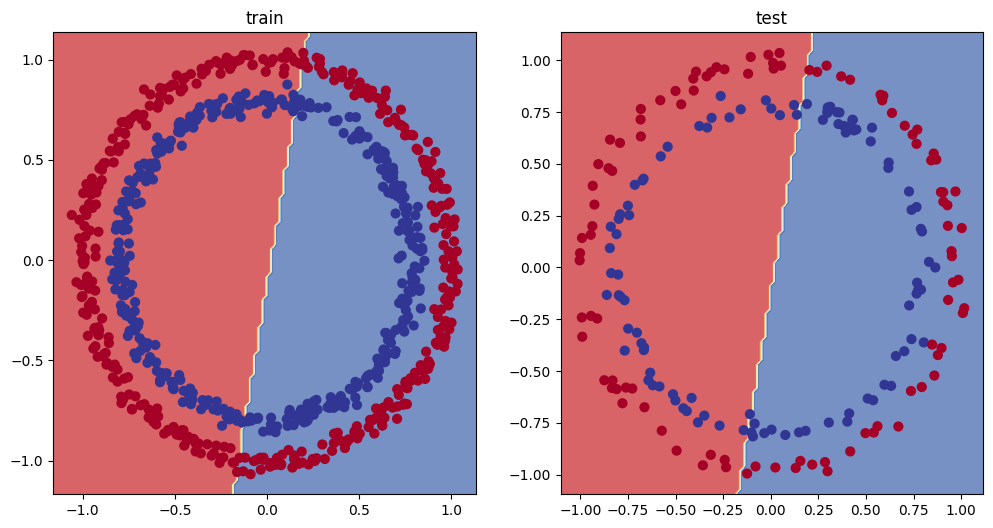

In [28]:
#plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_0,X_test,y_test)

In [29]:
#5.improving the model
#add more layers
#add more hidden units
#fit for longer
#changing the activation function
#changing the learning rate
#change the loss function

class circlemodelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2,out_features=10)
        self.layer_2=nn.Linear(in_features=10,out_features=10)
        self.layer_3=nn.Linear(in_features=10,out_features=1)
        
    def forward(self,x):
        # z=self.layer_1(x)
        # z=self.layer_2(z)
        # z=self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x)))
    
model_1=circlemodelv1().to(device)
model_1
            

circlemodelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [30]:
#create a loss function
loss_fn=nn.BCEWithLogitsLoss()

#optimizer
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [31]:
# building and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number the epochs
epochs=1000

#put data to target device
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

#building training and evaluation loop 
for epoch in range(epochs):
    #training
    model_1.train()
    
    #forward pass
    y_logits=model_1(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))#logits->pred probablities ->predictions
    
    #calulate the loss
    loss=loss_fn(y_logits,y_train)
    acc=accurracy_fn(y_true=y_train,y_pred=y_pred)
    #optimzer
    optimizer.zero_grad()
    
    #loss backward
    loss.backward()
    
    #optimizer step
    optimizer.step()
    
    #testing
    model_1.eval()
    
    with torch.inference_mode():
        #1.forward pass
        test_logits=model_1(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))
        
        #2.calculate the loss
        test_loss=loss_fn(test_logits,y_test)
        
        test_acc=accurracy_fn(y_true=y_test,y_pred=test_pred)
        
    #print out what's happening
    if epoch%100==0:
        print(f"Epoch:{epoch} | Loss:{loss:.5f} | Acc:{acc:.2f}% | Test Loss:{test_loss:.5f} | Test Acc:{test_acc:.2f}%")

Epoch:0 | Loss:0.69396 | Acc:50.88% | Test Loss:0.69261 | Test Acc:51.00%
Epoch:100 | Loss:0.69305 | Acc:50.38% | Test Loss:0.69379 | Test Acc:48.00%
Epoch:200 | Loss:0.69299 | Acc:51.12% | Test Loss:0.69437 | Test Acc:46.00%
Epoch:300 | Loss:0.69298 | Acc:51.62% | Test Loss:0.69458 | Test Acc:45.00%
Epoch:400 | Loss:0.69298 | Acc:51.12% | Test Loss:0.69465 | Test Acc:46.00%
Epoch:500 | Loss:0.69298 | Acc:51.00% | Test Loss:0.69467 | Test Acc:46.00%
Epoch:600 | Loss:0.69298 | Acc:51.00% | Test Loss:0.69468 | Test Acc:46.00%
Epoch:700 | Loss:0.69298 | Acc:51.00% | Test Loss:0.69468 | Test Acc:46.00%
Epoch:800 | Loss:0.69298 | Acc:51.00% | Test Loss:0.69468 | Test Acc:46.00%
Epoch:900 | Loss:0.69298 | Acc:51.00% | Test Loss:0.69468 | Test Acc:46.00%


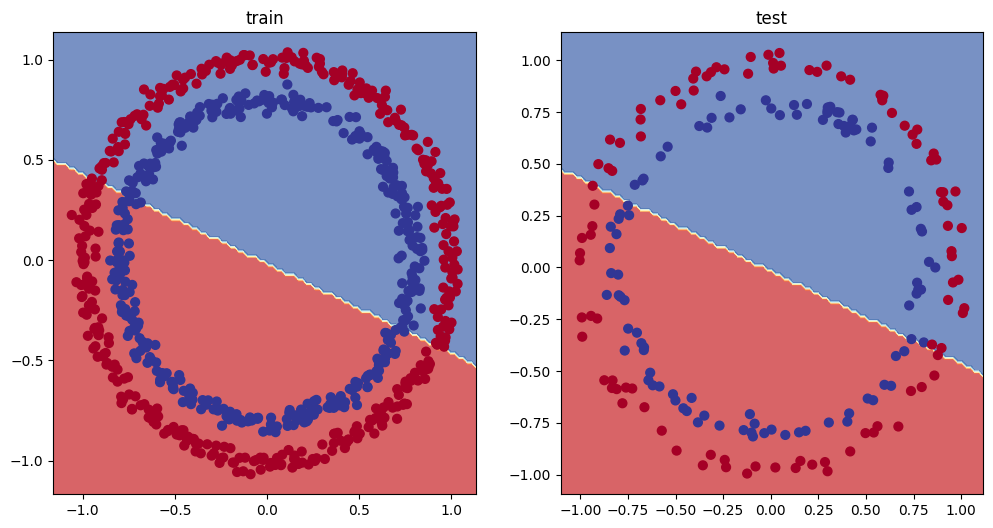

In [32]:
#plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_1,X_test,y_test)

In [33]:
#5.1 prepraing data to see if our model can fir a straight line
#create some data
weight=0.7
bias=0.3
start=0
end=1
step=0.01

#create data
X_regression=torch.arange(start,end,step).unsqueeze(dim=1)
y_regression=weight*X_regression+bias

#check the data
print(len(X_regression))
X_regression[:5],y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [34]:
#create train and test split
train_split=int(0.8*len(X_regression))
X_train_regression,y_train_regression=X_regression[:train_split],y_regression[:train_split]
X_test_regression,y_test_regression=X_regression[train_split:],y_regression[train_split:]

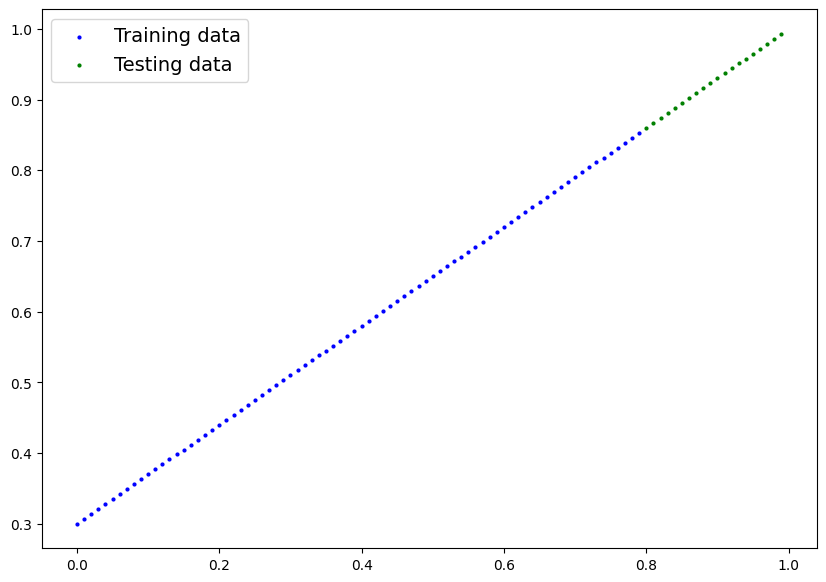

In [35]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression
                 )

In [36]:
#5.2adjusting the model to fit a straight line
model_2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)


In [37]:
#loss and optimizer
loss_fn=nn.L1Loss()

optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.01)

In [38]:
#train the model
# building and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number the epochs
epochs=1000

#put data to target device
X_train_regression,y_train_regression=X_train_regression.to(device),y_train_regression.to(device)
X_test_regression,y_test_regression=X_test_regression.to(device),y_test_regression.to(device)

#building training and evaluation loop 
for epoch in range(epochs):
    y_pred=model_2(X_train_regression)
    loss=loss_fn(y_pred,y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
   
   #testing
    model_2.eval()
    with torch.inference_mode():
       test_pred=model_2(X_test_regression)
       test_loss=loss_fn(test_pred,y_test_regression)
       
    #print out
    if epoch%100==0:
        print(f"epoch:{epoch} | loss:{loss:.5f} | test_loss:{test_loss:.5f}")

epoch:0 | loss:0.75986 | test_loss:0.91103


epoch:100 | loss:0.02858 | test_loss:0.00081
epoch:200 | loss:0.02533 | test_loss:0.00209
epoch:300 | loss:0.02137 | test_loss:0.00305
epoch:400 | loss:0.01964 | test_loss:0.00341
epoch:500 | loss:0.01940 | test_loss:0.00387
epoch:600 | loss:0.01903 | test_loss:0.00379
epoch:700 | loss:0.01878 | test_loss:0.00381
epoch:800 | loss:0.01840 | test_loss:0.00329
epoch:900 | loss:0.01798 | test_loss:0.00360


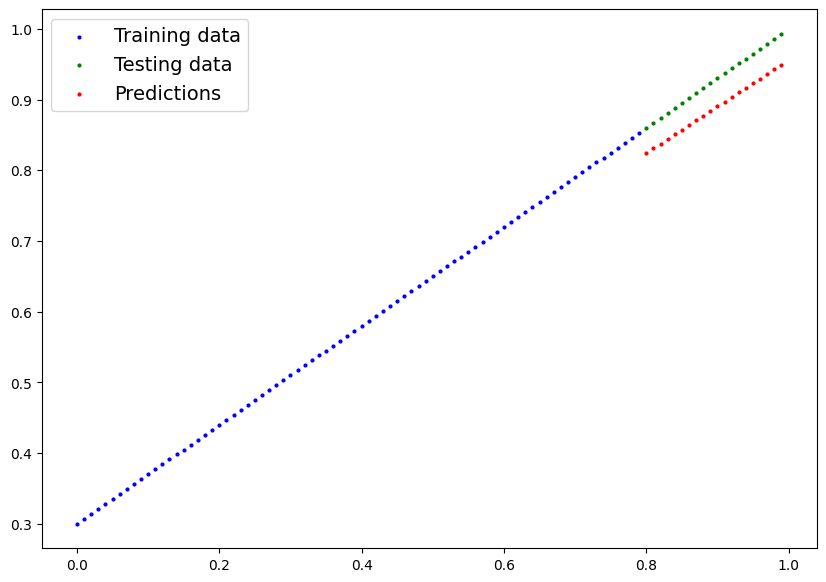

In [39]:
#turn on evaluation mode
model_2.eval()

#make predictions 
with torch.inference_mode():
    y_preds=model_2(X_test_regression)
    
#plot the data and predictions
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())

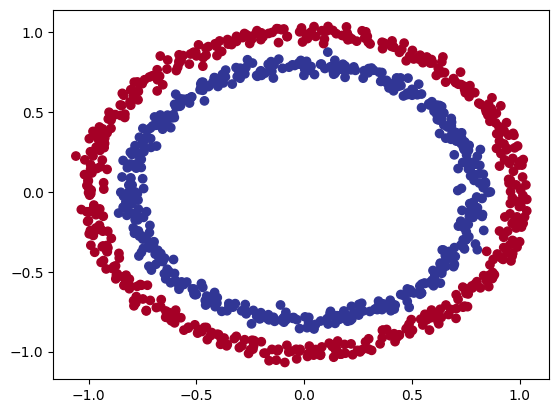

In [40]:
#6.the missing piece:non-linearity
#6.1 recreating non-linear data(red and blue circle)

from sklearn.datasets import make_circles

n_samples=1000

X,y=make_circles(n_samples,noise=0.03,random_state=42)
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [41]:
X[:5],y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [42]:
#make a dataframe of circle data
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [43]:
#convert data to tensors and then to rain and test splits
from sklearn.model_selection import train_test_split

#turn data into tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

#split into train and test cases
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [45]:
#6.2 building a model with non-linearity
#build a model with a non_linear function
from torch import nn
class circlemodelv3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2,out_features=10)
        self.layer_2=nn.Linear(in_features=10,out_features=10)
        self.layer_3=nn.Linear(in_features=10,out_features=1)
        self.relu=nn.ReLU()#relu is non-linear activation function
        
    
    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_3=circlemodelv3().to(device)
model_3

circlemodelv3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [46]:
#loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()

optimizer=torch.optim.SGD(params=model_3.parameters(),lr=0.1)

In [47]:
# building and testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number the epochs
epochs=1000

#put data to target device
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

#building training and evaluation loop 
for epoch in range(epochs):
    #training
    model_3.train()
    
    #forward pass
    y_logits=model_3(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))#logits->pred probablities ->predictions
    
    #calulate the loss
    loss=loss_fn(y_logits,y_train)
    acc=accurracy_fn(y_true=y_train,y_pred=y_pred)
    #optimzer
    optimizer.zero_grad()
    
    #loss backward
    loss.backward()
    
    #optimizer step
    optimizer.step()
    
    #testing
    model_3.eval()
    
    with torch.inference_mode():
        #1.forward pass
        test_logits=model_3(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))
        
        #2.calculate the loss
        test_loss=loss_fn(test_logits,y_test)
        
        test_acc=accurracy_fn(y_true=y_test,y_pred=test_pred)
        
    #print out what's happening
    if epoch%100==0:
        print(f"Epoch:{epoch} | Loss:{loss:.5f} | Acc:{acc:.2f}% | Test Loss:{test_loss:.5f} | Test Acc:{test_acc:.2f}%")

Epoch:0 | Loss:0.69295 | Acc:50.00% | Test Loss:0.69319 | Test Acc:50.00%
Epoch:100 | Loss:0.69115 | Acc:52.88% | Test Loss:0.69102 | Test Acc:52.50%
Epoch:200 | Loss:0.68977 | Acc:53.37% | Test Loss:0.68940 | Test Acc:55.00%
Epoch:300 | Loss:0.68795 | Acc:53.00% | Test Loss:0.68723 | Test Acc:56.00%
Epoch:400 | Loss:0.68517 | Acc:52.75% | Test Loss:0.68411 | Test Acc:56.50%
Epoch:500 | Loss:0.68102 | Acc:52.75% | Test Loss:0.67941 | Test Acc:56.50%
Epoch:600 | Loss:0.67515 | Acc:54.50% | Test Loss:0.67285 | Test Acc:56.00%
Epoch:700 | Loss:0.66659 | Acc:58.38% | Test Loss:0.66322 | Test Acc:59.00%
Epoch:800 | Loss:0.65160 | Acc:64.00% | Test Loss:0.64757 | Test Acc:67.50%
Epoch:900 | Loss:0.62362 | Acc:74.00% | Test Loss:0.62145 | Test Acc:79.00%


In [48]:
#make predictions
model_3.eval()

with torch.inference_mode():
    y_preds=torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_pred[:10],y_test[:10]

(tensor([1., 0., 0., 0., 1., 1., 1., 1., 0., 0.], device='cuda:0',
        grad_fn=<SliceBackward0>),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

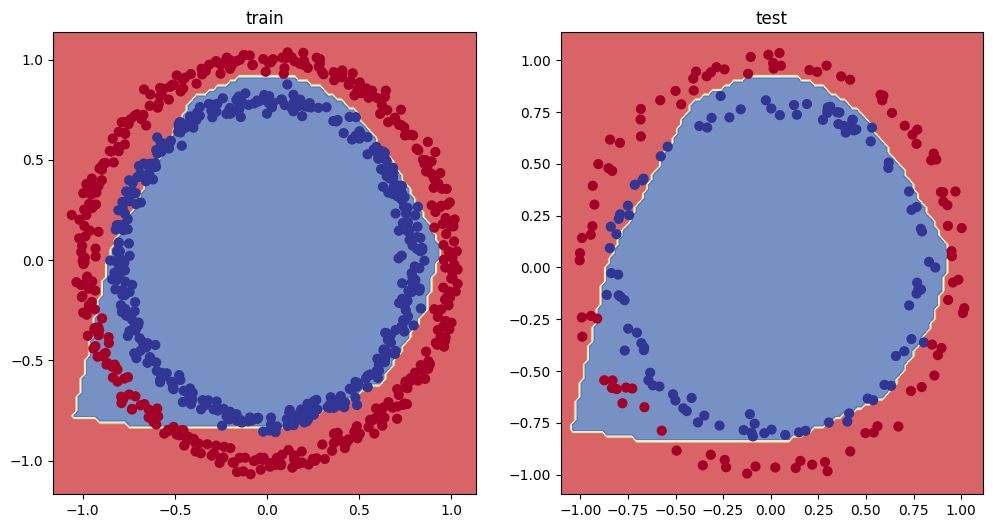

In [49]:
#plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_3,X_test,y_test)

In [52]:
#replicating non_linear function
#these tools are linear and non-linear functions
#create a tensor

A=torch.arange(-10,10,1,dtype=torch.float32)


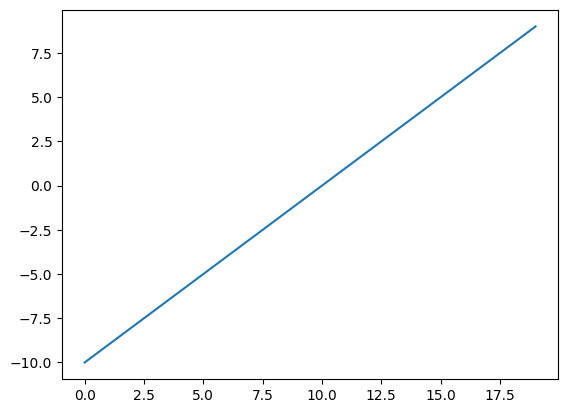

In [53]:
#visualize the tensor
plt.plot(A)

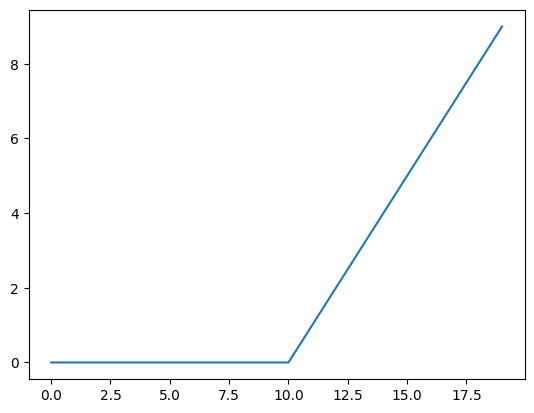

In [54]:
plt.plot(torch.relu(A))

In [55]:
def relu(X):
    return torch.maximum(torch.tensor(0),X)#input must be tensors

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

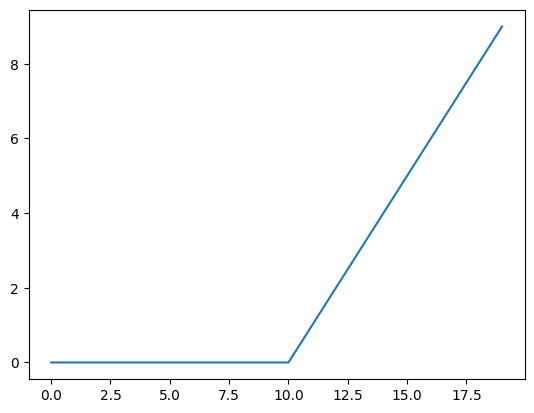

In [56]:
#plot relu
plt.plot(relu(A))